# Augmented Replication of Lopez Empirical Results

This notebook mirrors the empirical structure of Nicholas Lopez's *Dynamic, Welfare-Maximizing Pooled Testing* and applies it to the current augmented pooled testing codebase.

The goal is not to copy Lopez's exact binary-test experiments. Instead, we keep the same small-instance regimes and table structure, then add the augmented count-outcome algorithms implemented in `augmented/`.

This version focuses only on exact small-instance replication plus the augmented extension. Large-scale experiments are left out of scope for now.

In [1]:
from pathlib import Path
import sys, math, random, time
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
elif (ROOT / 'augmented').exists():
    pass
else:
    ROOT = Path('/Users/hectorbecerrilvillamil/Desktop/PooledTesting/pooled-testing-dynamic')

sys.path.insert(0, str(ROOT))

from augmented.baselines import u_single, u_max
from augmented.static_solver import solve_static_non_overlapping, solve_static_overlapping
from augmented.classical_solver import solve_classical_dynamic
from augmented.solver import solve_optimal_dapts
from augmented.greedy import (
    greedy_myopic_expected_utility,
    greedy_myopic_counting_expected_utility,
)
from augmented.independence_gap import gap_summary
from augmented.core import mask_from_indices

pd.set_option('display.max_columns', 60)
print(ROOT)

/Users/hectorbecerrilvillamil/Desktop/PooledTesting/pooled-testing-dynamic


## 1. Instance generation

Lopez's small-instance experiments sample each agent's health probability and utility independently from the uniform distribution on `[0,1]`.

The augmented code represents `p_i` as probability of infection. Therefore this notebook samples health probability `q_i` and passes `p_i = 1 - q_i` to the solvers.

In [2]:
def sample_small_instance(n, rng):
    health = [rng.random() for _ in range(n)]
    infection = [1.0 - q for q in health]
    utility = [rng.random() for _ in range(n)]
    return infection, utility, health


def stderr(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return values.std(ddof=1) / math.sqrt(len(values))

## 2. Small exact evaluation

These functions evaluate all pure-Python algorithms currently available for small instances:

- non-pooled / individual testing,
- static non-overlapping,
- static overlapping,
- optimal classical dynamic testing,
- optimal augmented dynamic testing,
- augmented myopic greedy,
- augmented counting-posterior greedy.

The default sample size is intentionally modest for interactive work. Set `NUM_SMALL = 1000` to match Lopez's table size.

In [3]:
def evaluate_small_instance(p, u, B, G):
    return {
        'Non-Pooled': u_single(p, u, B)[0],
        'Static Non-Overlapping': solve_static_non_overlapping(p, u, B, G)[0],
        'Static Overlapping': solve_static_overlapping(p, u, B, G)[0],
        'Classical Dynamic Optimal': solve_classical_dynamic(p, u, B, G)[0],
        'Augmented Greedy Dynamic': greedy_myopic_expected_utility(p, u, B, G),
        'Augmented Counting Greedy': greedy_myopic_counting_expected_utility(p, u, B, G),
        'Augmented Dynamic Optimal': solve_optimal_dapts(p, u, B, G)[0],
        'Upper Bound': u_max(p, u),
    }


def run_small_experiment(n, B, G, num_instances=100, seed=0):
    rng = random.Random(seed)
    rows = []
    t0 = time.time()
    for instance_id in range(num_instances):
        p, u, health = sample_small_instance(n, rng)
        values = evaluate_small_instance(p, u, B, G)
        base = {
            'instance': instance_id,
            'n': n,
            'B': B,
            'G': G,
            'avg_health': float(np.mean(health)),
            'avg_utility': float(np.mean(u)),
        }
        for algorithm, value in values.items():
            rows.append({**base, 'algorithm': algorithm, 'value': value})
    df = pd.DataFrame(rows)
    print(f'Completed n={n}, B={B}, G={G}, instances={num_instances} in {time.time()-t0:.2f}s')
    return df


def summarize_values(df):
    return (
        df.groupby(['n', 'G', 'B', 'algorithm'])['value']
        .agg(avg='mean', se=stderr, count='count')
        .reset_index()
        .sort_values(['n', 'G', 'B', 'avg'])
    )

NUM_SMALL = 100  # use 1000 for the thesis-scale table
small_332 = run_small_experiment(n=3, B=2, G=3, num_instances=NUM_SMALL, seed=20250603)
small_553 = run_small_experiment(n=5, B=3, G=5, num_instances=NUM_SMALL, seed=20250604)
small_results = pd.concat([small_332, small_553], ignore_index=True)
small_summary = summarize_values(small_results)
small_summary

Completed n=3, B=2, G=3, instances=100 in 0.06s
Completed n=5, B=3, G=5, instances=100 in 14.49s


,n,G,B,algorithm,avg,se,count
4,3,3,2,Non-Pooled,0.667106,0.034482,100
0,3,3,2,Augmented Counting Greedy,0.681743,0.037137,100
2,3,3,2,Augmented Greedy Dynamic,0.681743,0.037137,100
5,3,3,2,Static Non-Overlapping,0.686399,0.037272,100
6,3,3,2,Static Overlapping,0.690421,0.038190,100
3,3,3,2,Classical Dynamic Optimal,0.697160,0.038778,100
1,3,3,2,Augmented Dynamic Optimal,0.699867,0.038912,100
7,3,3,2,Upper Bound,0.749006,0.041186,100
12,5,5,3,Non-Pooled,1.068244,0.039951,100
13,5,5,3,Static Non-Overlapping,1.094110,0.041752,100


## 3. Thesis-style table

The next cell formats the small-instance results in a table similar to Lopez's Table 6.1.

In [ ]:
def thesis_style_table(summary):
    out = summary.copy()
    out['Average Expected Welfare'] = out.apply(lambda r: f"{r['avg']:.4f} ({r['se']:.5f})", axis=1)
    out['Constraints'] = out.apply(lambda r: f"N = G = {int(r['n'])}, B = {int(r['B'])}" if r['n'] == r['G'] else f"N={int(r['n'])}, G={int(r['G'])}, B={int(r['B'])}", axis=1)
    return out[['Constraints', 'algorithm', 'Average Expected Welfare']]

table_61_augmented = thesis_style_table(small_summary)
table_61_augmented

In [ ]:
# Save notebook-generated table for LaTeX copy/paste or downstream use.
out_dir = ROOT / 'augmented' / 'data'
out_dir.mkdir(parents=True, exist_ok=True)
table_path = out_dir / 'nick_style_augmented_small_summary.csv'
small_path = out_dir / 'nick_style_augmented_small_long.csv'
table_61_augmented.to_csv(table_path, index=False)
small_results.to_csv(small_path, index=False)
print(table_path)
print(small_path)

## 4. Pairwise dominance table

Lopez also reports the percentage of instances in which one algorithm outperforms another. The next cell reproduces that analysis for the small augmented experiments.

In [ ]:
def pairwise_win_table(df, n, B, G, algorithms=None):
    sub = df[(df.n == n) & (df.B == B) & (df.G == G)]
    wide = sub.pivot_table(index='instance', columns='algorithm', values='value')
    if algorithms is None:
        algorithms = [c for c in wide.columns if c != 'Upper Bound']
    result = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
    for row_alg in algorithms:
        for col_alg in algorithms:
            if row_alg == col_alg:
                result.loc[row_alg, col_alg] = np.nan
            else:
                # Entry: percentage of instances where column algorithm beats row algorithm.
                result.loc[row_alg, col_alg] = 100.0 * (wide[col_alg] > wide[row_alg]).mean()
    return result

algorithms_small = [
    'Static Overlapping',
    'Classical Dynamic Optimal',
    'Augmented Greedy Dynamic',
    'Augmented Counting Greedy',
    'Augmented Dynamic Optimal',
]

wins_332 = pairwise_win_table(small_results, n=3, B=2, G=3, algorithms=algorithms_small)
wins_553 = pairwise_win_table(small_results, n=5, B=3, G=5, algorithms=algorithms_small)
wins_332

In [ ]:
wins_553

## 5. Augmented value over classical dynamic testing

This isolates the value of count outcomes. The classical and augmented optimal dynamic solvers use the same population, budget, and pool-size constraint; they differ only in the information returned by a positive test.

In [6]:
def augmented_gain_summary(df):
    wide = df.pivot_table(index=['n', 'G', 'B', 'instance'], columns='algorithm', values='value').reset_index()
    wide['aug_minus_classical'] = wide['Augmented Dynamic Optimal'] - wide['Classical Dynamic Optimal']
    wide['aug_pct_gain_vs_classical'] = np.where(
        wide['Classical Dynamic Optimal'] > 1e-12,
        100.0 * wide['aug_minus_classical'] / wide['Classical Dynamic Optimal'],
        np.nan,
    )
    return wide.groupby(['n', 'G', 'B']).agg(
        mean_gain=('aug_minus_classical', 'mean'),
        se_gain=('aug_minus_classical', stderr),
        mean_pct_gain=('aug_pct_gain_vs_classical', 'mean'),
        fraction_strictly_better=('aug_minus_classical', lambda x: float((x > 1e-10).mean())),
    ).reset_index()

aug_gain = augmented_gain_summary(small_results)
aug_gain

,n,G,B,mean_gain,se_gain,mean_pct_gain,fraction_strictly_better
0,3,3,2,0.002707,0.000639,0.376778,0.46
1,5,5,3,0.034672,0.002731,3.263722,0.95


## 6. Independence gap example

The greedy algorithm uses posterior marginals. After overlapping or count-based tests, marginals can be correct while the product-of-marginals approximation is wrong. This cell constructs the canonical example: a test on `{0,1}` returns count `1`.

In [5]:
p = [0.5, 0.5, 0.2]
n = 3
history = ((mask_from_indices([0, 1]), 1),)
pool = mask_from_indices([0, 1])
gap_summary(p, history, pool, n)

{'pool_size': 2,
 'exact_pmf': [0.0, 1.0, 0.0],
 'heuristic_pmf': [0.25, 0.5, 0.25],
 'tv': 0.5,
 'gap_r0': 0.25,
 'gap_rmax': 0.25,
 'abs_gap_r0': 0.25,
 'abs_gap_rmax': 0.25}

## 7. Figures

These lightweight plots reproduce the two most useful views from the thesis-style analysis: value distributions by algorithm and augmented-vs-classical gains.

/var/folders/zn/lnx_6ksj0r1b93bw0d12m0mm0000gn/T/ipykernel_29083/1012058720.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, vert=True, showfliers=False)


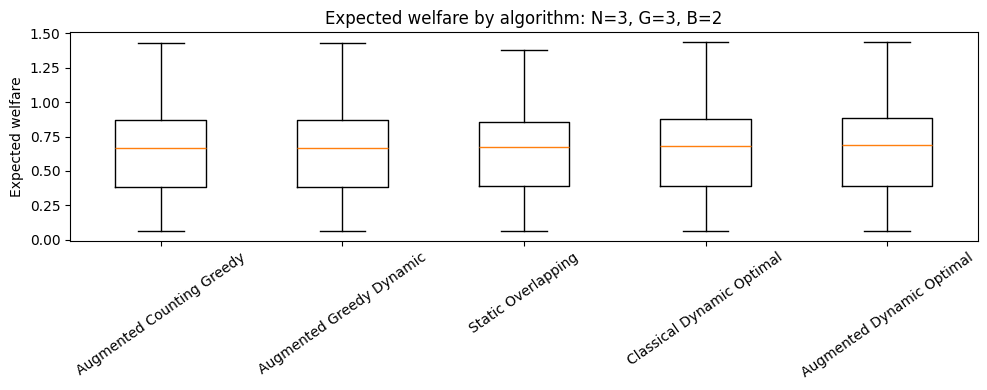

/var/folders/zn/lnx_6ksj0r1b93bw0d12m0mm0000gn/T/ipykernel_29083/1012058720.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, vert=True, showfliers=False)


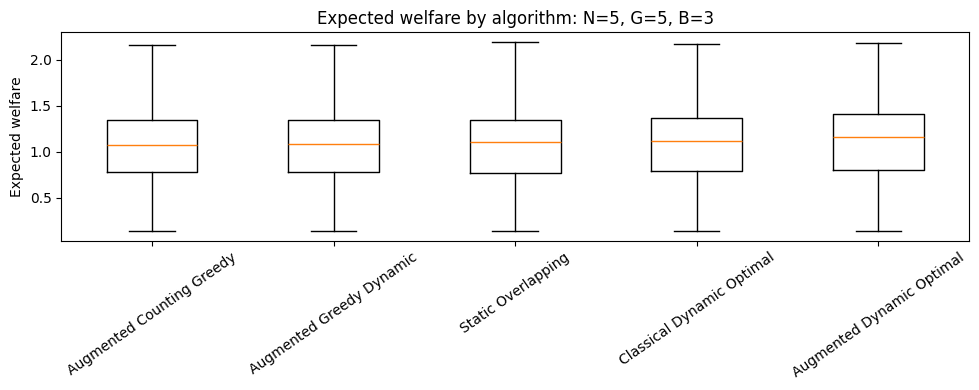

In [4]:
import matplotlib.pyplot as plt

plot_df = small_results[small_results['algorithm'].isin([
    'Static Overlapping',
    'Classical Dynamic Optimal',
    'Augmented Greedy Dynamic',
    'Augmented Counting Greedy',
    'Augmented Dynamic Optimal',
])].copy()

for (n, G, B), sub in plot_df.groupby(['n', 'G', 'B']):
    fig, ax = plt.subplots(figsize=(10, 4))
    order = sub.groupby('algorithm')['value'].mean().sort_values().index.tolist()
    data = [sub[sub.algorithm == alg]['value'].values for alg in order]
    ax.boxplot(data, labels=order, vert=True, showfliers=False)
    ax.set_title(f'Expected welfare by algorithm: N={n}, G={G}, B={B}')
    ax.set_ylabel('Expected welfare')
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.show()

## 8. Notes for the LaTeX draft

The companion draft is located at:

`docs/notes/augmented_empirical_results_nick_style.tex`

After running this notebook at the desired sample size, copy the generated table values from `augmented/data/nick_style_augmented_small_summary.csv` into the LaTeX table, or add a `pgfplotstable`/CSV import if the main paper build supports it.